## Plot UKAQR data
- This script is used to visualize UKAQR distributions of O3 and PM2.5

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from shapely.geometry import Point 
from zhiyi.plot.cbar import Cbar

In [ ]:

# # O3
gdf = gpd.read_file("/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_Ozone_Gridded_-4374955293643276370.gpkg")

# PM25 
# gdf = gpd.read_file("/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_PM2p5_Gridded_3075619853497766146.gpkg")


gdf["stdTime"] = pd.to_datetime(gdf["stdTime"]) 
start = pd.Timestamp("2017-12-01", tz="UTC")
end   = pd.Timestamp("2018-12-01", tz="UTC") 

mask = (gdf["stdTime"] >= start) & (gdf["stdTime"] < end)
gdf_sel = gdf.loc[mask].copy()

# gdf_avg = gdf.groupby("gridID", as_index=False).agg(
#     mean_avg=("mean", "mean")
# )

gdf_avg = gdf_sel.groupby("gridID", as_index=False).agg(
    mean_avg=("mean", "mean")
)

gdf_avg = gdf_avg.merge(
    gdf.drop_duplicates("gridID")[["gridID", "geometry"]],
    on="gridID",
    how="left"
)

gdf_avg = gpd.GeoDataFrame(gdf_avg, geometry="geometry")

bounds = gdf_avg.geometry.bounds 
gdf_avg["lon"] = (bounds["minx"] + bounds["maxx"]) / 2
gdf_avg["lat"] = (bounds["miny"] + bounds["maxy"]) / 2

df = gdf_avg[["lon", "lat", "mean_avg"]].copy()

pivot = df.pivot(index="lat", columns="lon", values="mean_avg")

lon_centers = pivot.columns.values.astype(float)
lat_centers = pivot.index.values.astype(float)

dlon = np.median(np.diff(lon_centers))
dlat = np.median(np.diff(lat_centers))

lon_edges = np.concatenate((
    [lon_centers[0] - dlon/2],
    (lon_centers[1:] + lon_centers[:-1]) / 2,
    [lon_centers[-1] + dlon/2]
))

lat_edges = np.concatenate((
    [lat_centers[0] - dlat/2],
    (lat_centers[1:] + lat_centers[:-1]) / 2,
    [lat_centers[-1] + dlat/2]
))

lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)

data2d = pivot.values  
factor = 1 
data2d_ppbv = data2d * factor
lonc2d, latc2d = np.meshgrid(lon_centers, lat_centers)

cbar_obj = Cbar("myct_cont")
cmap = cbar_obj.cmap

ne_admin1 = gpd.read_file(
    "/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp"
)

if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
    ne_admin1 = ne_admin1.to_crs(epsg=4326)
# ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IRL","IMN"])]
ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR","IMN"])]

uk_ie_union = ne_uk_ie.union_all()
points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lonc2d.ravel(), latc2d.ravel()),
    crs="EPSG:4326"
)

inside = points.within(uk_ie_union).values 
mask = inside.reshape(data2d.shape)          

data2d_masked = np.where(mask, data2d_ppbv, np.nan)

/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-11-16T00:00:00.0Z, successfully parsed
  return ogr_read(


Text(0.02, 0.98, '(b)')

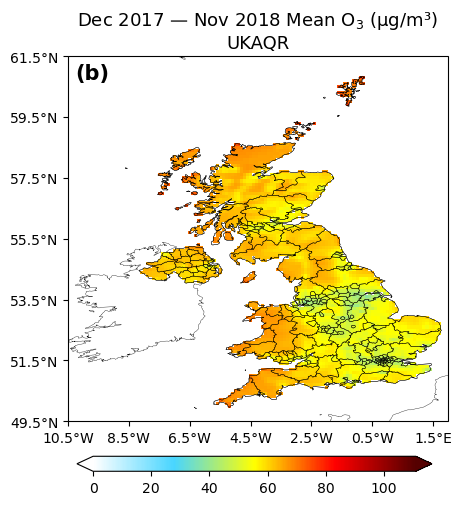

In [ ]:

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1, projection=proj)

pcm = ax.pcolormesh(
    lon2d, lat2d, data2d_masked,
    shading="auto",
    transform=proj,
    cmap=cmap,
    vmin=0,
    # vmax=13.5
    vmax=111
)

ax.set_extent([-10, 2, 50, 59], crs=proj)

ax.coastlines("10m", linewidth=0.25)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.25)

ax.add_geometries(
    ne_uk_ie.geometry,
    crs=proj,
    facecolor="none",
    edgecolor="black",
    linewidth=0.3
)

xticks = np.arange(-10.5, 3, 2)
yticks = np.arange(49.5, 62, 2)
ax.set_xticks(xticks, crs=proj)
ax.set_yticks(yticks, crs=proj)

ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

fig.subplots_adjust(bottom=0.15)

cax = fig.add_axes([0.15, 0.05, 0.71, 0.03])
cb = plt.colorbar(pcm, cax=cax, orientation="horizontal", extend="both")

ax.set_title("Dec 2017 — Nov 2018 Mean O$_3$ (µg/m³) \nUKAQR", fontsize=13)
# ax.set_title("Dec 2017 — Nov 2018 Mean PM$_{2.5}$ (µg/m³) \nUKAQR", fontsize=13)

ax.text(
    0.02, 0.98, "(b)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=15,
    fontweight="bold"
)



In [ ]:

# # O3
# gdf = gpd.read_file("/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_Ozone_Gridded_-4374955293643276370.gpkg")

# PM25
gdf = gpd.read_file("/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_PM2p5_Gridded_3075619853497766146.gpkg")

gdf["stdTime"] = pd.to_datetime(gdf["stdTime"]) 

start = pd.Timestamp("2017-12-01", tz="UTC")
end   = pd.Timestamp("2018-12-01", tz="UTC")  

mask = (gdf["stdTime"] >= start) & (gdf["stdTime"] < end)
gdf_sel = gdf.loc[mask].copy()
# ---------------------------------------------

# gdf_avg = gdf.groupby("gridID", as_index=False).agg(
#     mean_avg=("mean", "mean")
# )

gdf_avg = gdf_sel.groupby("gridID", as_index=False).agg(
    mean_avg=("mean", "mean")
)

gdf_avg = gdf_avg.merge(
    gdf.drop_duplicates("gridID")[["gridID", "geometry"]],
    on="gridID",
    how="left"
)

gdf_avg = gpd.GeoDataFrame(gdf_avg, geometry="geometry")

bounds = gdf_avg.geometry.bounds 
gdf_avg["lon"] = (bounds["minx"] + bounds["maxx"]) / 2
gdf_avg["lat"] = (bounds["miny"] + bounds["maxy"]) / 2

df = gdf_avg[["lon", "lat", "mean_avg"]].copy()
pivot = df.pivot(index="lat", columns="lon", values="mean_avg")

lon_centers = pivot.columns.values.astype(float)
lat_centers = pivot.index.values.astype(float)

dlon = np.median(np.diff(lon_centers))
dlat = np.median(np.diff(lat_centers))

lon_edges = np.concatenate((
    [lon_centers[0] - dlon/2],
    (lon_centers[1:] + lon_centers[:-1]) / 2,
    [lon_centers[-1] + dlon/2]
))

lat_edges = np.concatenate((
    [lat_centers[0] - dlat/2],
    (lat_centers[1:] + lat_centers[:-1]) / 2,
    [lat_centers[-1] + dlat/2]
))

lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)

data2d = pivot.values  
factor = 1 
data2d_ppbv = data2d * factor

lonc2d, latc2d = np.meshgrid(lon_centers, lat_centers)

cbar_obj = Cbar("myct_cont")
cmap = cbar_obj.cmap

ne_admin1 = gpd.read_file(
    "/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp")

if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
    ne_admin1 = ne_admin1.to_crs(epsg=4326)

# ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IRL","IMN"])]
ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR","IMN"])]

uk_ie_union = ne_uk_ie.union_all()

points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lonc2d.ravel(), latc2d.ravel()),
    crs="EPSG:4326"
)

inside = points.within(uk_ie_union).values  
mask = inside.reshape(data2d.shape)          

data2d_masked = np.where(mask, data2d_ppbv, np.nan)


/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-12-16T12:00:00.0Z, successfully parsed
  return ogr_read(


Text(0.02, 0.98, '(f)')

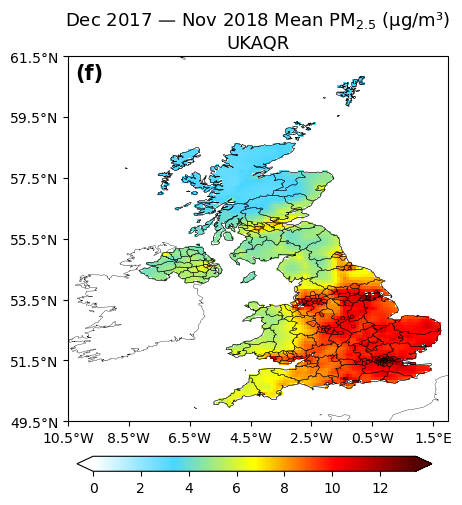

In [ ]:

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1, projection=proj)

pcm = ax.pcolormesh(
    lon2d, lat2d, data2d_masked,
    shading="auto",
    transform=proj,
    cmap=cmap,
    vmin=0,
    vmax=13.5
)

ax.set_extent([-10, 2, 50, 59], crs=proj)

ax.coastlines("10m", linewidth=0.25)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.25)

ax.add_geometries(
    ne_uk_ie.geometry,
    crs=proj,
    facecolor="none",
    edgecolor="black",
    linewidth=0.3
)

xticks = np.arange(-10.5, 3, 2) 
yticks = np.arange(49.5, 62, 2)
ax.set_xticks(xticks, crs=proj)
ax.set_yticks(yticks, crs=proj)

ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

fig.subplots_adjust(bottom=0.15)
cax = fig.add_axes([0.15, 0.05, 0.71, 0.03])
cb = plt.colorbar(pcm, cax=cax, orientation="horizontal", extend="both")
# ax.set_title("Dec 2017 — Nov 2018 Mean O$_3$ (µg/m³) \nUKAQR", fontsize=13)
ax.set_title("Dec 2017 — Nov 2018 Mean PM$_{2.5}$ (µg/m³) \nUKAQR", fontsize=13)

ax.text(
    0.02, 0.98, "(f)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=15,
    fontweight="bold"
)


In [9]:
gdfO3 = gpd.read_file("/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_Ozone_Gridded_-4374955293643276370.gpkg")
gdfO3

/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-11-16T00:00:00.0Z, successfully parsed
  return ogr_read(


,gridID,SHAPE_Leng,latitude,longitude,stdTime,join_gridID,mean,geometry
0,7838.0,0.4,54.700001,357.500000,2017-11-16 00:00:00+00:00,7838,59.478180,"MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4..."
1,7838.0,0.4,54.700001,357.500000,2017-12-16 12:00:00+00:00,7838,59.028194,"MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4..."
2,7838.0,0.4,54.700001,357.500000,2018-01-16 12:00:00+00:00,7838,61.434856,"MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4..."
3,7838.0,0.4,54.700001,357.500000,2018-02-15 00:00:00+00:00,7838,64.229263,"MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4..."
4,7838.0,0.4,54.700001,357.500000,2018-03-16 12:00:00+00:00,7838,72.018509,"MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4..."
...,...,...,...,...,...,...,...,...
96565,3250.0,0.4,51.299999,361.100006,2018-09-16 00:00:00+00:00,3250,55.072891,"MULTIPOLYGON (((1.05 51.25, 1.15 51.25, 1.15 5..."
96566,3250.0,0.4,51.299999,361.100006,2018-10-16 12:00:00+00:00,3250,46.430073,"MULTIPOLYGON (((1.05 51.25, 1.15 51.25, 1.15 5..."
96567,3250.0,0.4,51.299999,361.100006,2018-11-16 00:00:00+00:00,3250,37.077076,"MULTIPOLYGON (((1.05 51.25, 1.15 51.25, 1.15 5..."
96568,3250.0,0.4,51.299999,361.100006,2018-12-16 12:00:00+00:00,3250,44.037754,"MULTIPOLYGON (((1.05 51.25, 1.15 51.25, 1.15 5..."


In [10]:
gdfPM25 = gpd.read_file("/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_PM2p5_Gridded_3075619853497766146.gpkg")
gdfPM25

/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-12-16T12:00:00.0Z, successfully parsed
  return ogr_read(


,gridID,SHAPE_Leng,latitude,longitude,stdTime,join_gridID,mean,geometry
0,7838.0,0.4,54.700001,357.500000,2017-12-16 12:00:00+00:00,7838,1.734054,"MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4..."
1,7838.0,0.4,54.700001,357.500000,2018-01-16 12:00:00+00:00,7838,3.442349,"MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4..."
2,7838.0,0.4,54.700001,357.500000,2018-02-15 00:00:00+00:00,7838,4.327513,"MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4..."
3,7838.0,0.4,54.700001,357.500000,2018-03-16 12:00:00+00:00,7838,5.514441,"MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4..."
4,7838.0,0.4,54.700001,357.500000,2018-04-16 00:00:00+00:00,7838,6.009806,"MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4..."
...,...,...,...,...,...,...,...,...
90127,3250.0,0.4,51.299999,361.100006,2018-09-16 00:00:00+00:00,3250,6.674146,"MULTIPOLYGON (((1.05 51.25, 1.15 51.25, 1.15 5..."
90128,3250.0,0.4,51.299999,361.100006,2018-10-16 12:00:00+00:00,3250,9.213841,"MULTIPOLYGON (((1.05 51.25, 1.15 51.25, 1.15 5..."
90129,3250.0,0.4,51.299999,361.100006,2018-11-16 00:00:00+00:00,3250,11.983429,"MULTIPOLYGON (((1.05 51.25, 1.15 51.25, 1.15 5..."
90130,3250.0,0.4,51.299999,361.100006,2018-12-16 12:00:00+00:00,3250,7.909092,"MULTIPOLYGON (((1.05 51.25, 1.15 51.25, 1.15 5..."


In [5]:
print(gdf.head())
print(gdf.columns)

   gridID  SHAPE_Leng   latitude  longitude                   stdTime  \
0  7838.0         0.4  54.700001      357.5 2017-11-16 00:00:00+00:00   
1  7838.0         0.4  54.700001      357.5 2017-12-16 12:00:00+00:00   
2  7838.0         0.4  54.700001      357.5 2018-01-16 12:00:00+00:00   
3  7838.0         0.4  54.700001      357.5 2018-02-15 00:00:00+00:00   
4  7838.0         0.4  54.700001      357.5 2018-03-16 12:00:00+00:00   

   join_gridID       mean                                           geometry  
0         7838  59.478180  MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4...  
1         7838  59.028194  MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4...  
2         7838  61.434856  MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4...  
3         7838  64.229263  MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4...  
4         7838  72.018509  MULTIPOLYGON (((-2.55 54.65, -2.45 54.65, -2.4...  
Index(['gridID', 'SHAPE_Leng', 'latitude', 'longitude', 'stdTime',
       'join_gridID'

In [9]:
print(gdf.crs)

EPSG:4326
